#Importy

In [11]:
!pip install nrclex

In [12]:
import re
from collections import defaultdict
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string
import plotly.express as px
import plotly.graph_objects as go
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import LatentDirichletAllocation
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import spacy
import warnings
warnings.filterwarnings('ignore')
from textblob import TextBlob
from plotly.subplots import make_subplots
from textblob import TextBlob
from plotly.subplots import make_subplots
from nrclex import NRCLex
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
import seaborn as sns
import pandas as pd


In [13]:
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

#Pomocnicze metody

##wczytanie skryptu

In [14]:
def wczytaj_skrypt(nazwa_pliku):
    with open(nazwa_pliku, 'r', encoding='utf-8') as plik:
        return plik.read()


##wyodrębnienie zdań postaci

Zdanie postaci to linia występująca bezpośrednio po linii z nazwą postaci (które zawsze pisane są z dużych liter) i [POCZATEK_DIALOGU].
Jako klucz używam tylko pierwszego słowa nazwy postaci. tak aby np. LUKE oraz LUKE (through comlink) były traktowane jak taka sama postać.

In [15]:
def wyodrebnij_zdania_postaci(tekst):

    linie = tekst.split('\n')

    zdania_postaci = defaultdict(list)

    i = 0
    while i < len(linie) - 1:
        if '[POCZATEK_DIALOGU]' in linie[i]:
            pelna_nazwa = linie[i].split('[POCZATEK_DIALOGU]')[0].strip()
            postac = pelna_nazwa.split()[0]

            if i + 1 < len(linie):
                if linie[i + 1].strip().startswith('(') and linie[i + 1].strip().endswith(')'):
                    if i + 2 < len(linie) and linie[i + 2].strip():
                        zdanie = linie[i + 2].strip()
                        zdania_postaci[postac].append(zdanie)
                        i += 3
                        continue
                else:
                    if linie[i + 1].strip():
                        zdanie = linie[i + 1].strip()
                        zdania_postaci[postac].append(zdanie)
        i += 1

    klucze_do_usuniecia = []
    for klucz in zdania_postaci.keys():
        if klucz in ['INT.', 'EXT.', 'INT', 'EXT'] or any(c.isdigit() for c in klucz):
            klucze_do_usuniecia.append(klucz)

    for klucz in klucze_do_usuniecia:
        del zdania_postaci[klucz]

    return zdania_postaci

##podstawowe przetworzenie tekstu

In [16]:
def przetworz_tekst_podstawowo(tekst):
    tekst = tekst.lower()

    tekst = tekst.translate(str.maketrans("", "", string.punctuation))

    tekst = re.sub(r'\d+', '', tekst)

    tokeny = word_tokenize(tekst)

    return tokeny

##przetworzenie slow zaawansowane

In [17]:
def przetworz_tekst_zaawansowanie(tekst):

    tokeny = przetworz_tekst_podstawowo(tekst)

    slowa_stop = set(stopwords.words('english'))
    dodatkowe_slowa_stop = {
        'dont', 'youre', 'youll', 'youd', 'youve', 'thats', 'thats', 'theyre',
        'theyve', 'theyll', 'theyd', 'shes', 'shed', 'shell', 'hes', 'hed',
        'hell', 'ive', 'im', 'id', 'ill', 'were', 'weve', 'wed', 'well',
        'arent', 'isnt', 'wasnt', 'werent', 'havent', 'hasnt', 'hadnt',
        'didnt', 'doesnt', 'wont', 'wouldnt', 'couldnt', 'shouldnt', 'cant',
        'cannot', 'aint', 'gonna', 'wanna', 'gotta', 'lemme', 'gimme', 'gotta',
        'ya', 'yeah', 'yes', 'no', 'ok', 'okay', 'hey', 'hi', 'hello', 'oh',
        'ah', 'um', 'uh', 'er', 'hmm', 'huh', 'ha', 'ha', 'heh', 'hehe',
        'lol', 'wow', 'whoa', 'whoah', 'whoops', 'oops', 'ouch', 'ow', 'oww'
    }
    slowa_stop.update(dodatkowe_slowa_stop)

    tokeny = [slowo for slowo in tokeny if slowo not in slowa_stop]

    tokeny = [slowo for slowo in tokeny if len(slowo) > 2]

    lematyzator = WordNetLemmatizer()
    tokeny = [lematyzator.lemmatize(slowo) for slowo in tokeny]

    return tokeny

Rozbiłem czyszczenie tekstu na podstawowe oraz zaawansowane, tak aby zachować większość sensu zdań w dialogach postaci, ale też mieć mocno wyczyszczony słownik do celu budowy chmur słów

#Przygotowanie plików tekstowych

Oryginalne skrypty filmowe z 4, 5 i 6 części Gwiezdnych Wojen w formacie PDF zostały przekonwertowane na plik Word. Podczas konwersji plik Word automatycznie zamieniał imiona postaci na akapity, a także dodawał linijkę odstępu między nazwą postaci a jej dialogiem. W dialogach postaci, linijki były oddzielone od siebie spacjami, a cała część dialogowa była oddzielona od opisu sceny za pomocą enteru. Na podstawie tego formatu stworzyłem program, który generuje sformatowany plik tekstowy (.txt). Program wstawia przed nazwą postaci oznaczenie [POCZĄTEK_DIALOGU], a cały dialog postaci umieszczany jest w jednej linii, co ułatwia jego późniejsze oddzielenie od reszty tekstu. Program znajduje się na clasroomie razem z resztą projektu

#Wczytanie i wstępne przetworzenie danych

##Pliki do wczytania

In [18]:
pliki = {
    'nowa_nadzieja': 'nowa_nadzieja_format.txt',
    'imperium_kontratakuje': 'imperium_kontratakuje_format.txt',
    'powrot_jedi': 'powrot_jedi_format.txt'
}

##Słowniki z danymi

In [19]:
zdania_postaci_filmy = {}  # Dialogi postaci według filmów
zdania_filmow = {}         # Wszystkie zdania z każdego filmu
termy_filmow_podstawowe = {}  # Podstawowo wyczyszczone termy z każdego filmu
termy_filmow_zaawansowane = {}  # Zaawansowanie wyczyszczone termy z każdego filmu - wykorzystywane w chmurach słów
zdania_postaci = defaultdict(list)  # Wszystkie zdania każdej postaci
termy_postaci_podstawowe = defaultdict(list)  # Podstawowo wyczyszczone termy każdej postaci
termy_postaci_zaawansowane = defaultdict(list)  # Zaawansowanie wyczyszczone termy każdej postaci - wykorzystywane w chmurach słów

##Przetworzenie tekstu oraz załadowanie słowników dla filmów i postaci

In [20]:
for nazwa_filmu, nazwa_pliku in pliki.items():

    tekst_skryptu = wczytaj_skrypt(nazwa_pliku)

    zdania_postaci_filmy[nazwa_filmu] = wyodrebnij_zdania_postaci(tekst_skryptu)

    wszystkie_zdania = []
    for zdania in zdania_postaci_filmy[nazwa_filmu].values():
        wszystkie_zdania.extend(zdania)

    zdania_filmow[nazwa_filmu] = wszystkie_zdania
    wszystkie_zdania_tekst = ' '.join(wszystkie_zdania)
    termy_filmow_podstawowe[nazwa_filmu] = przetworz_tekst_podstawowo(wszystkie_zdania_tekst)
    termy_filmow_zaawansowane[nazwa_filmu] = przetworz_tekst_zaawansowanie(wszystkie_zdania_tekst)

    for postac, zdania in zdania_postaci_filmy[nazwa_filmu].items():
        zdania_postaci[postac].extend(zdania)

##Zmiana zdań postaci na termy

In [21]:
for postac, zdania in zdania_postaci.items():
    wszystkie_zdania_tekst = ' '.join(zdania)
    termy_postaci_podstawowe[postac] = przetworz_tekst_podstawowo(wszystkie_zdania_tekst)
    termy_postaci_zaawansowane[postac] = przetworz_tekst_zaawansowanie(wszystkie_zdania_tekst)

#Podstawowe statystyki filmów i wykresy

##Ilość postaci w każdym filmie i ilość zdań każdej postaci

In [22]:
for nazwa_filmu, postaci in zdania_postaci_filmy.items():
    print(f"\nStatystyki dla filmu: {nazwa_filmu}")
    print(f"W filmie znajduje się {len(postaci)} postaci")
    for postac, zdania in postaci.items():
        print(f"{postac}: {len(zdania)} zdań")


Statystyki dla filmu: nowa_nadzieja
W filmie znajduje się 55 postaci
FROM: 1 zdań
THREEPIO: 116 zdań
LUKE: 244 zdań
IMPERIAL: 2 zdań
VADER: 41 zdań
REBEL: 1 zdań
TROOPER: 20 zdań
CHIEF: 3 zdań
CAPTAIN: 1 zdań
WOMAN: 1 zdań
FIXER: 2 zdań
CAMIE: 2 zdań
BIGGS: 33 zdań
DEAK: 1 zdań
LEIA: 57 zdań
COMMANDER: 3 zdań
SECOND: 4 zdań
FIRST: 7 zdań
BERU: 1 zdań
OWEN: 25 zdań
(MORE): 10 zdań
AUNT: 6 zdań
INT./EXT.: 1 zdań
BEN: 74 zdań
TAGGE: 4 zdań
MOTTI: 4 zdań
TARKIN: 27 zdań
BARTENDER: 3 zdań
CREATURE: 1 zdań
HUMAN: 4 zdań
HAN: 140 zdań
GREEDO: 6 zdań
JABBA: 6 zdań
OFFICER: 11 zdań
VOICE: 4 zdań
HAN'S: 1 zdań
GANTRY: 2 zdań
INTERCOM: 6 zdań
BEN'S: 6 zdań
WILLARD: 2 zdań
DEATH: 6 zdań
DODONNA: 5 zdań
GOLD: 17 zdań
WEDGE: 10 zdań
MAN'S: 1 zdań
RED: 35 zdań
MASSASSI: 3 zdań
READ: 1 zdań
ASTRO-OFFICER: 1 zdań
CONTROL: 1 zdań
LUKE'S: 1 zdań
WINGMAN'S: 1 zdań
BASE: 1 zdań
WINGMAN: 1 zdań
TECHNICIAN: 1 zdań

Statystyki dla filmu: imperium_kontratakuje
W filmie znajduje się 46 postaci
LUKE: 122 zdań
H

W filmach "Nowa nadzieja", "Imperium kontratakuje" oraz "Powrót Jedi" dialogi są rozdzielone pomiędzy różne postacie, z największą liczbą zdań przypisaną do głównych bohaterów, takich jak Luke, Han, Leia, Vader i Threepio, a reszta postaci ma zdecydowanie mniejszy udział w dialogach, co pokazuje dominację kilku kluczowych postaci w rozmowach.

##Liczba zdań i termów dla każdego filmu

In [23]:
print("\nLiczba zdań w każdym filmie:")
for film, zdania in zdania_filmow.items():
    print(f"{film}: {len(zdania)} zdań")

print("\nLiczba termów w każdym filmie:")
for film, termy in termy_filmow_podstawowe.items():
    print(f"{film}: {len(termy)} termów")


Liczba zdań w każdym filmie:
nowa_nadzieja: 968 zdań
imperium_kontratakuje: 808 zdań
powrot_jedi: 670 zdań

Liczba termów w każdym filmie:
nowa_nadzieja: 10490 termów
imperium_kontratakuje: 7265 termów
powrot_jedi: 6263 termów


##Wykres słupkowy dla 5 postaci z największą ilością słów w każdym filmie

In [24]:
for film in pliki.keys():
    slowa_postaci = {}
    for postac, zdania in zdania_postaci_filmy[film].items():
        wszystkie_zdania_tekst = ' '.join(zdania)
        termy = przetworz_tekst_podstawowo(wszystkie_zdania_tekst)
        slowa_postaci[postac] = len(termy)

    top_5 = dict(sorted(slowa_postaci.items(), key=lambda x: x[1], reverse=True)[:5])

    fig = px.bar(x=list(top_5.keys()), y=list(top_5.values()),
                 title=f'Top 5 postaci z największą liczbą słów - {film}',
                 labels={'x': 'Postać', 'y': 'Liczba słów'})
    fig.write_html(f'top_5_postaci_{film}.html')
    fig.show()

"Nowa nadzieja": Główna postać, Luke, ma zdecydowanie najwięcej słów, wynosząc ponad 2000 słów. Kolejni bohaterowie, tacy jak Han (ponad 1500 słów) i Threepio (ponad 1000 słów), również mają znaczną ilość dialogów. Inne postacie, takie jak Leia, Ben, czy Vader, mają znacznie mniej wypowiedzi, co wskazuje na dominację głównych bohaterów w dialogach.

"Imperium kontratakuje": W tym filmie dominują Han (ponad 1400 słów) i Threepio (ponad 1200 słów), a Luke (ponad 1000 słów) oraz Vader (ponad 600 słów) również mają znaczną liczbę wypowiedzi. Mimo że film ma większą liczbę postaci, główni bohaterowie nadal przeważają pod względem liczby słów.

"Powrót Jedi": W tym filmie Han i Threepio mają również dominującą liczbę słów (ponad 900 i 800 słów), a Luke oraz Ben (ponad 700 słów) również mają istotny udział w dialogach. Względnie mniej dialogów mają postacie takie jak Emperor i inne drugoplanowe postacie, co podkreśla znaczenie kluczowych bohaterów w rozmowach.

##Wykres porównawczy dla top 5 postaci z największą ilością słów

In [25]:
laczne_slowa = {}
for postac in zdania_postaci.keys():
    wszystkie_zdania_tekst = ' '.join(zdania_postaci[postac])
    termy = przetworz_tekst_podstawowo(wszystkie_zdania_tekst)
    laczne_slowa[postac] = len(termy)

top_5_global = dict(sorted(laczne_slowa.items(), key=lambda x: x[1], reverse=True)[:5])

dane_porownawcze = []
for postac in top_5_global.keys():
    for film in pliki.keys():
        if postac in zdania_postaci_filmy[film]:
            wszystkie_zdania_tekst = ' '.join(zdania_postaci_filmy[film][postac])
            termy = przetworz_tekst_podstawowo(wszystkie_zdania_tekst)
            slowa = len(termy)
            dane_porownawcze.append({
                'Postać': postac,
                'Film': film,
                'Liczba słów': slowa
            })

fig = px.bar(dane_porownawcze, x='Postać', y='Liczba słów', color='Film',
             title='Porównanie liczby słów dla top 5 postaci między filmami',
             barmode='group')
fig.write_html('porownanie_postaci_miedzy_filmami.html')
fig.show()

Wraz z każdym kolejnym filmem liczba słów wypowiedzianych przez Luke’a stopniowo maleje. W "Nowej nadziei" Luke ma zdecydowaną dominację, jednak w "Imperium kontratakuje" i "Powrocie Jedi" jego liczba słów jest coraz mniejsza w porównaniu do innych postaci, takich jak Han czy Threepio. Ogólnie rzecz biorąc, wraz z kolejnymi filmami liczba dialogów w całej produkcji również się zmniejsza.

## Rozkład długości zdań dla top 5 postaci

In [26]:
dane_dlugosci = []
for postac in top_5_global.keys():
    for zdanie in zdania_postaci[postac]:
        dlugosc = len(zdanie.split())
        dane_dlugosci.append({
            'Postać': postac,
            'Długość zdania': dlugosc
        })

fig = px.box(dane_dlugosci, x='Postać', y='Długość zdania',
             title='Rozkład długości zdań dla top 5 postaci',
             points='all')
fig.write_html('dlugosc_zdan_postaci.html')
fig.show()

Wykres rozkładu długości zdań dla top 5 postaci w filmach pokazuje interesującą zależność dotyczącą długości wypowiedzi. Postacie starsze, takie jak Ben, mają zazwyczaj dłuższe zdania, co może wynikać z ich bardziej refleksyjnych i spokojnych wypowiedzi, które są bardziej skomplikowane i pełne treści. Z kolei młodsze, bardziej energiczne postacie, takie jak Luke, Han i Leia, często wypowiadają się krócej, z krótszymi zdaniami, co może odzwierciedlać ich dynamiczne i bezpośrednie podejście do rozmów.

#Chmury słów

##chmury słów dla każdego filmu

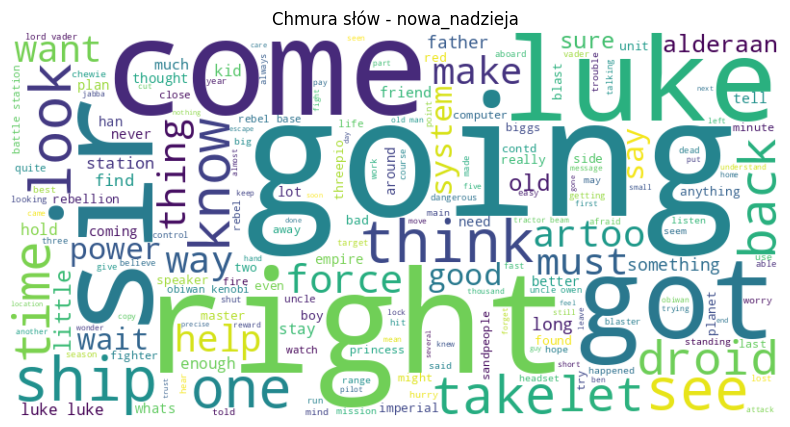

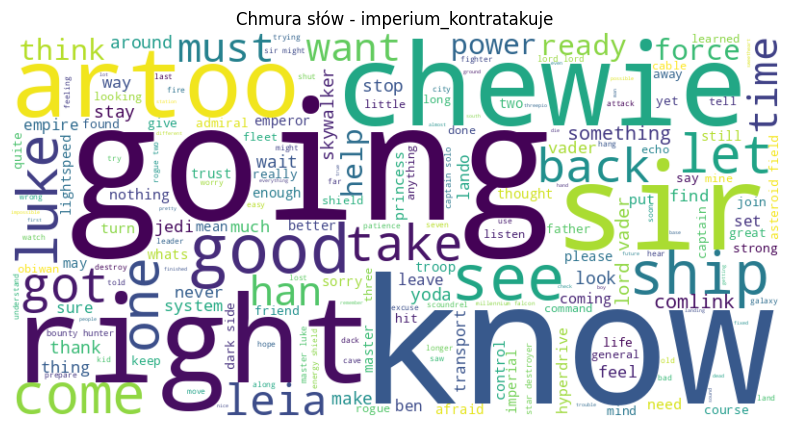

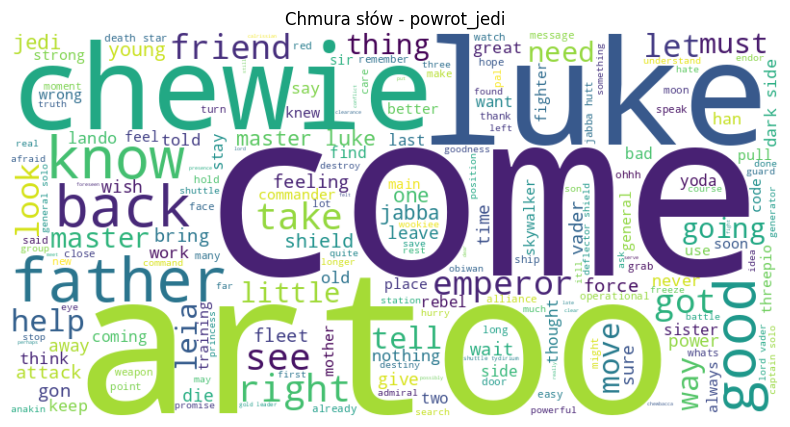

In [27]:
for film in pliki.keys():
    wszystkie_termy = ' '.join(termy_filmow_zaawansowane[film])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(wszystkie_termy)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Chmura słów - {film}')
    plt.savefig(f'chmura_slow_{film}.png')
    plt.show()

We wszystkich trzech filmach chmury słów silnie akcentują dynamikę akcji – dominują tu czasowniki ruchu („go”, „come”, „right”) i wezwania do natychmiastowego działania, jednak każda część ma swoje niuanse: w „Nowej nadziei” wyraźnie przebija się początek epickiej przygody z imionami Luke’a i droidów oraz zarys mistyki Mocy („force”), w „Imperium kontratakuje” pojawia się najczęściej „know”, co podkreśla odkrywanie kluczowych prawd i dramatyczne zwroty akcji (m.in. zwrot Skywalkera), a także rosnąca rola Yody, podczas gdy w „Powrocie Jedi” najbardziej uwydatniają się więzi między głównymi bohaterami („Chewie”, „Leia”, „Luke”) i motyw wzajemnej pomocy („help”, „need”) w ostatecznej konfrontacji z Jabba oraz Imperatorem.

##chmury słów dla top 5 postaci

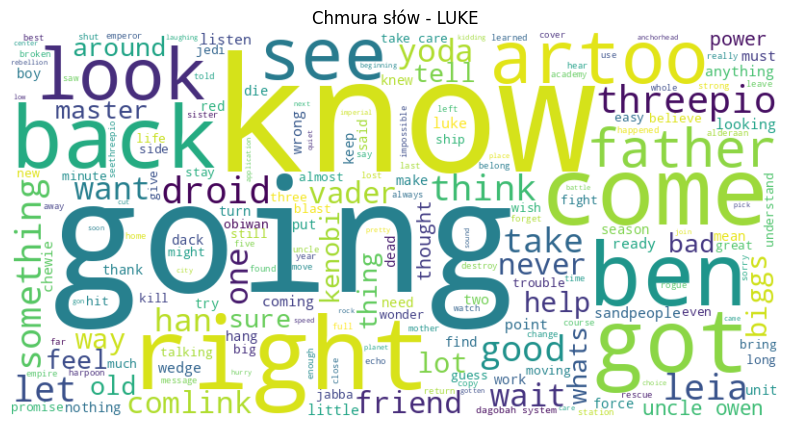

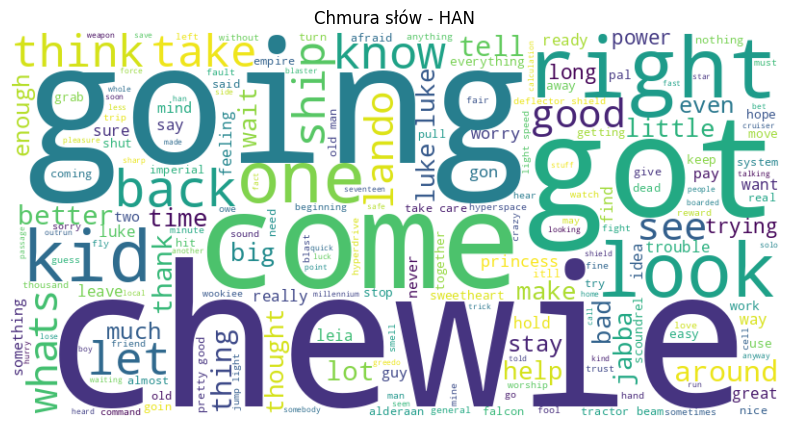

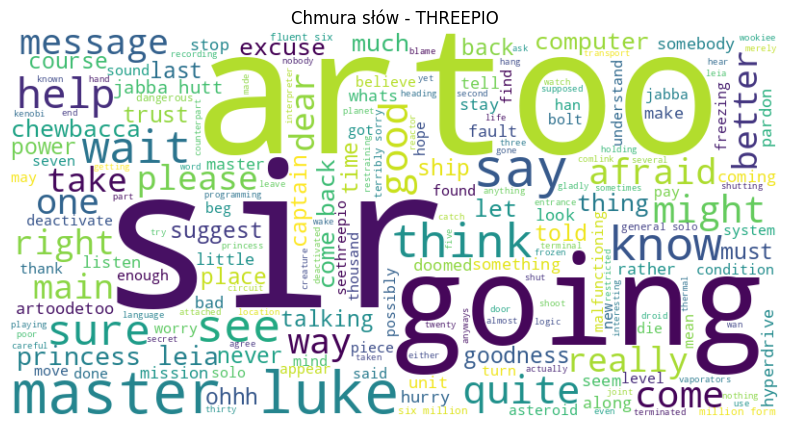

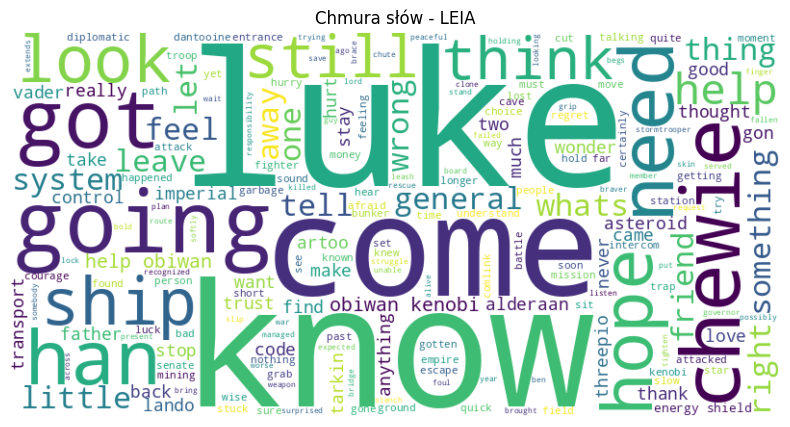

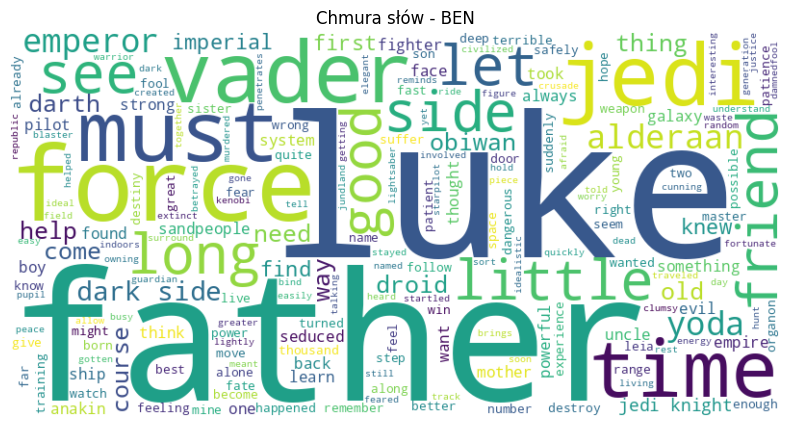

In [28]:
for postac in top_5_global.keys():
    wszystkie_termy = ' '.join(termy_postaci_zaawansowane[postac])

    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(wszystkie_termy)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Chmura słów - {postac}')
    plt.savefig(f'chmura_slow_{postac}.png')
    plt.show()


W chmurach słów dla poszczególnych postaci widać, że Ben koncentruje się na filozofii Jedi, relacjach rodzinnych i mocy, Leia jest zdeterminowana, skupiona na pomocy innym i walce z Imperium, Luke szuka sensu, koncentrując się na swojej roli jako Jedi i relacjach z ojcem, Threepio pełni rolę pomocniczą, pełną obaw i technicznych kwestii, natomiast Han jest dynamiczną postacią, lojalną wobec przyjaciół i pełną akcji. Każda z postaci ma swój unikalny styl wypowiedzi, odpowiadający ich roli i charakterystyce.

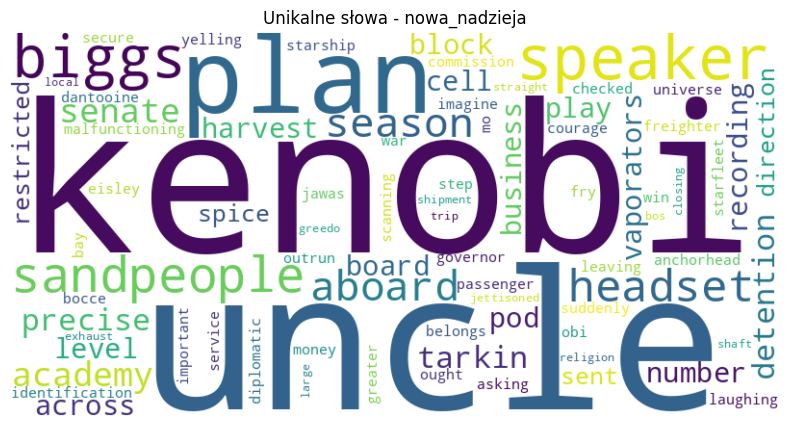

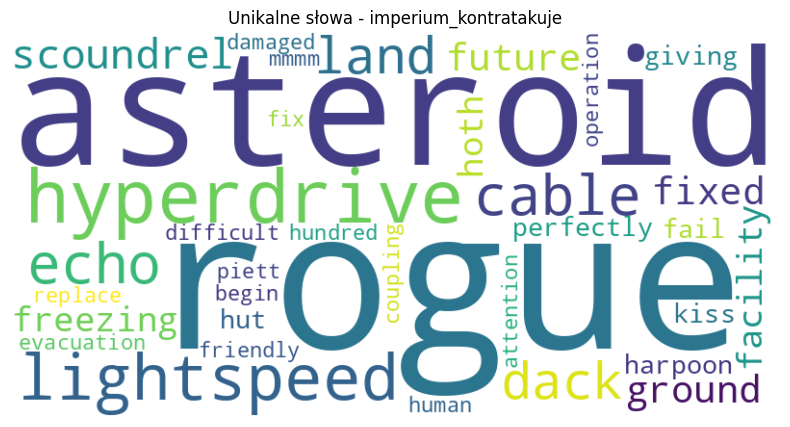

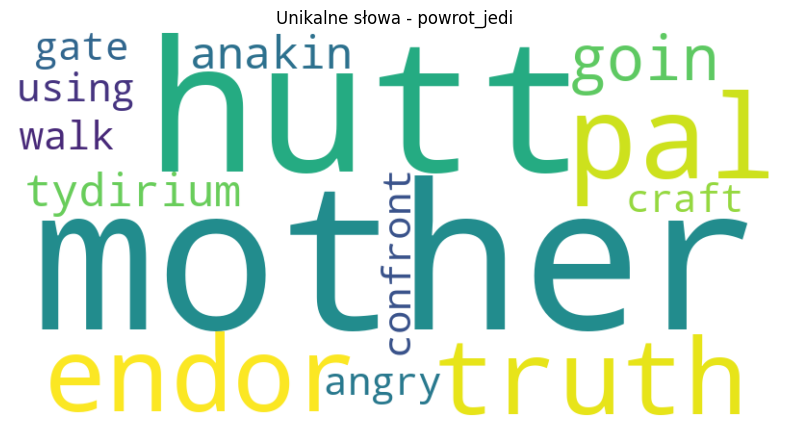

In [29]:
def znajdz_unikalne_slowa(slownik_termy, min_wystapienia=3):
    wszystkie_termy = []
    for termy in slownik_termy.values():
        wszystkie_termy.extend(termy)
    licznik_wszystkich = Counter(wszystkie_termy)

    unikalne_slowa = {}
    for klucz, termy in slownik_termy.items():
        licznik_klucza = Counter(termy)
        unikalne = {slowo: liczba for slowo, liczba in licznik_klucza.items()
                   if liczba >= min_wystapienia and liczba == licznik_wszystkich[slowo]}
        unikalne_slowa[klucz] = unikalne

    return unikalne_slowa

unikalne_slowa_filmy = znajdz_unikalne_slowa(termy_filmow_zaawansowane)

for film, unikalne in unikalne_slowa_filmy.items():
    if unikalne:
        wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(unikalne)
        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'Unikalne słowa - {film}')
        plt.savefig(f'unikalne_slowa_{film}.png')
        plt.show()
        plt.close()

W „Nowej nadziei” unikalne słowa jak „Kenobi”, „uncle” czy „sandpeople” podkreślają wprowadzenie kluczowych postaci i pustynnego świata Tatooine wraz z technicznymi detalami („headset”, „recording”), w „Imperium kontratakuje” dominują terminy wojskowo-techniczne („asteroid”, „hyperdrive”, „lightspeed”, „cable”) odzwierciedlające walkę o przetrwanie w polu asteroid i zmagania z napędem nadświetlnym, natomiast w „Powrocie Jedi” nazwy lokacji i emocjonalne motywy („hutt”, „endor”, „truth”, „mother”) akcentują ostateczne konfrontacje rodzinne oraz strategiczne szturmy na Endorze.

#Analiza Wątków dla 7 postaci z największą ilością słów

In [30]:
top_7_postaci = dict(sorted(laczne_slowa.items(), key=lambda x: x[1], reverse=True)[:7])

korpus_postaci_nmf = []
for postac in top_7_postaci.keys():
    tekst = ' '.join(termy_postaci_zaawansowane[postac])
    korpus_postaci_nmf.append(tekst)

vectorizer_nmf = TfidfVectorizer(max_features=1000, min_df=2, max_df=0.95)
X_nmf = vectorizer_nmf.fit_transform(korpus_postaci_nmf)

n_topics = 5
nmf = NMF(n_components=n_topics, random_state=42, l1_ratio=0.5)
nmf_output = nmf.fit_transform(X_nmf)

tematy = []
for i, postac in enumerate(top_7_postaci.keys()):
    for j in range(n_topics):
        tematy.append({
            'Postać': postac,
            'Temat': f'Temat {j+1}',
            'Udział': nmf_output[i][j]
        })

fig = px.bar(tematy, x='Postać', y='Udział', color='Temat',
             title='Rozkład tematów w dialogach 7 postaci z największą liczbą słów',
             barmode='stack')
fig.write_html('rozkład_tematow.html')
fig.show()

feature_names = vectorizer_nmf.get_feature_names_out()
for topic_idx, topic in enumerate(nmf.components_):
    top_words = [feature_names[i] for i in topic.argsort()[:-10-1:-1]]
    print(f"\nNajważniejsze słowa dla tematu: {topic_idx + 1}:")
    print(", ".join(top_words))


Najważniejsze słowa dla tematu: 1:
chewie, got, right, look, like, one, take, think, whats, could

Najważniejsze słowa dla tematu: 2:
father, jedi, force, vader, yoda, side, dark, emperor, darth, uncle

Najważniejsze słowa dla tematu: 3:
sir, artoo, master, say, message, wait, think, sure, might, right

Najważniejsze słowa dla tematu: 4:
emperor, master, obiwan, commander, admiral, force, plan, skywalker, son, destroy

Najważniejsze słowa dla tematu: 5:
right, fighter, han, vader, chewie, security, lord, small, hunter, bounty


Analiza podziału tematów w dialogach siedmiu najaktywniejszych postaci ukazuje wyraźne zróżnicowanie ich ról narracyjnych: Luke jest tu najbardziej wszechstronny – łączy wezwania do akcji (Temat 1), refleksje o Mocy i konflikcie z Vaderem (Temat 2), uprzejme formy grzecznościowe (Temat 3) oraz fragmenty odnoszące się do planów i strategii (Temat 4). Han i Leia niemal wyłącznie operują Tematem 1 („chewie”, „got”, „look”, „take”), co odzwierciedla ich dynamiczne, spontaniczne zaangażowanie w akcję. Threepio mówi głównie w tonie Tematu 3 („sir”, „message”, „master”), podkreślając swój formalny i służebny charakter, a Obi-Wan, skupia się na Temacie 2, poruszając kwestie Mocy, rodu Skywalkerów i konfliktu z ciemną stroną mocy. Vader dominuje w Temacie 4  pełni rolę wykonawcy cesarskich rozkazów („emperor”, „destroy”, „commander”), podczas gdy Lando w przeważającej mierze reprezentuje Temat 5, związany z wątkami militarnymi i przemytniczymi („security”, „bounty”, „fighter”).

#Dendrogram podobieństwa dla 10 postaci z największą ilością słów

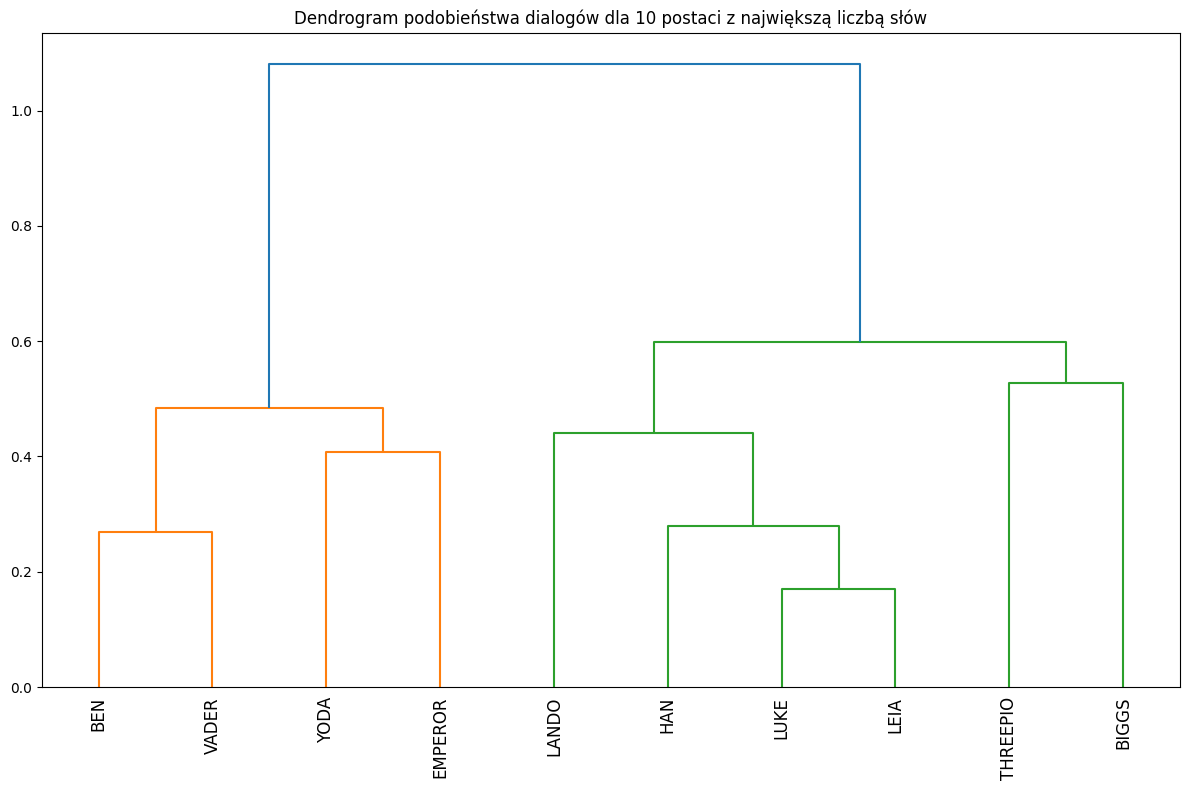

In [31]:
top_10_postaci = dict(sorted(laczne_slowa.items(), key=lambda x: x[1], reverse=True)[:10])

korpus_postaci = []
for postac in top_10_postaci.keys():
    tekst = ' '.join(zdania_postaci[postac])
    korpus_postaci.append(tekst)

vectorizer = TfidfVectorizer(max_features=1000)
X = vectorizer.fit_transform(korpus_postaci)

podobienstwo = cosine_similarity(X)

plt.figure(figsize=(12, 8))
linkage_matrix = linkage(podobienstwo, method='ward')
dendrogram(linkage_matrix, labels=list(top_10_postaci.keys()), leaf_rotation=90)
plt.title('Dendrogram podobieństwa dialogów dla 10 postaci z największą liczbą słów')
plt.tight_layout()
plt.savefig('dendrogram_postaci.png')
plt.show()

Dendrogram pokazuje, że w jednej grupie znajdują się postacie starsze, takie jak Ben, Vader, Yoda i Palpatine, które pojawiły się w prequelach. Można przypuszczać, że ich podobny styl wypowiedzi wynika z ich dojrzałości oraz poważnych ról, jakie pełnią jako mentorzy, władcy czy przewodnicy. W drugiej grupie są młodsze postacie, takie jak Han, Luke, Leia, Threepio, Biggs i Lando, których wypowiedzi są bardziej dynamiczne i mniej formalne, co jest typowe dla ich młodszych, bardziej energicznych ról w fabule.

In [32]:
from sklearn.cluster import AgglomerativeClustering
n_clusters = 3
clustering = AgglomerativeClustering(n_clusters=n_clusters, metric='cosine', linkage='average')
clusters = clustering.fit_predict(podobienstwo)

dane_klastrow = []
for i, postac in enumerate(top_10_postaci.keys()):
    dane_klastrow.append({
        'Postać': postac,
        'Klaster': f'Klaster {clusters[i] + 1}'
    })

fig = px.scatter(dane_klastrow, x='Postać', y='Klaster',
                 title='Grupowanie postaci na podstawie podobieństwa dialogów',
                 color='Klaster')
fig.write_html('klastry_postaci.html')
fig.show()

Grupowanie postaci wyraźnie odzwierciedla ich narracyjne role: w jednym klastrze (LUKE, HAN, LEIA, LANDO, BIGGS) znalazły się postacie o najbardziej dynamicznych, impulsywnych dialogach – pełnych wezwań do działania i spontanicznych reakcji. Drugi klaster (VADER, YODA, EMPEROR, BEN) łączy postaci autorytatywne bądź mistyczne, które mówią krótko, lecz ciążą ku refleksji nad Mocą i rozkazom. Osobno wyodrębnił się C-3PO, którego formalny, grzeczny styl („sir”, „message”, „master”) znacząco różni się od pozostałych bohaterów, co sprawiło, że znalazł się w trzeciom klastrze. To potwierdza, że podobieństwo dialogów silnie zależy od funkcji postaci w fabule.

#Klasyfikatory

##wybranie 7 postaci z największą ilością słów

In [33]:
top_7_postaci = dict(sorted(laczne_slowa.items(), key=lambda x: x[1], reverse=True)[:7])

## Przygotowanie danych do trenowania

In [34]:
X = []
y = []

for postac in top_7_postaci.keys():
    for zdanie in zdania_postaci[postac]:
        przetworzone_zdanie = ' '.join(przetworz_tekst_zaawansowanie(zdanie))
        if przetworzone_zdanie:
            X.append(przetworzone_zdanie)
            y.append(postac)

##Podział na zbiór treningowy i testowy

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Funkcja do oceny klasyfikatora

In [36]:
def ocen_klasyfikator(y_true, y_pred, y_prob=None):
    wyniki = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average='weighted'),
        'recall': recall_score(y_true, y_pred, average='weighted'),
        'f1': f1_score(y_true, y_pred, average='weighted')
    }
    return wyniki

## 1. Wektoryzacja binarna

In [37]:
vectorizer_binary = CountVectorizer(binary=True)
X_train_binary = vectorizer_binary.fit_transform(X_train)
X_test_binary = vectorizer_binary.transform(X_test)

classifier_binary = SVC(kernel='linear', probability=True)
classifier_binary.fit(X_train_binary, y_train)
y_pred_binary = classifier_binary.predict(X_test_binary)
wyniki_binary = ocen_klasyfikator(y_test, y_pred_binary)

              precision    recall  f1-score   support

         BEN       0.20      0.07      0.11        14
         HAN       0.41      0.48      0.44        90
       LANDO       0.12      0.05      0.07        21
        LEIA       0.18      0.17      0.18        41
        LUKE       0.42      0.54      0.47        91
    THREEPIO       0.60      0.48      0.53        58
       VADER       0.44      0.30      0.36        23

    accuracy                           0.40       338
   macro avg       0.34      0.30      0.31       338
weighted avg       0.39      0.40      0.39       338



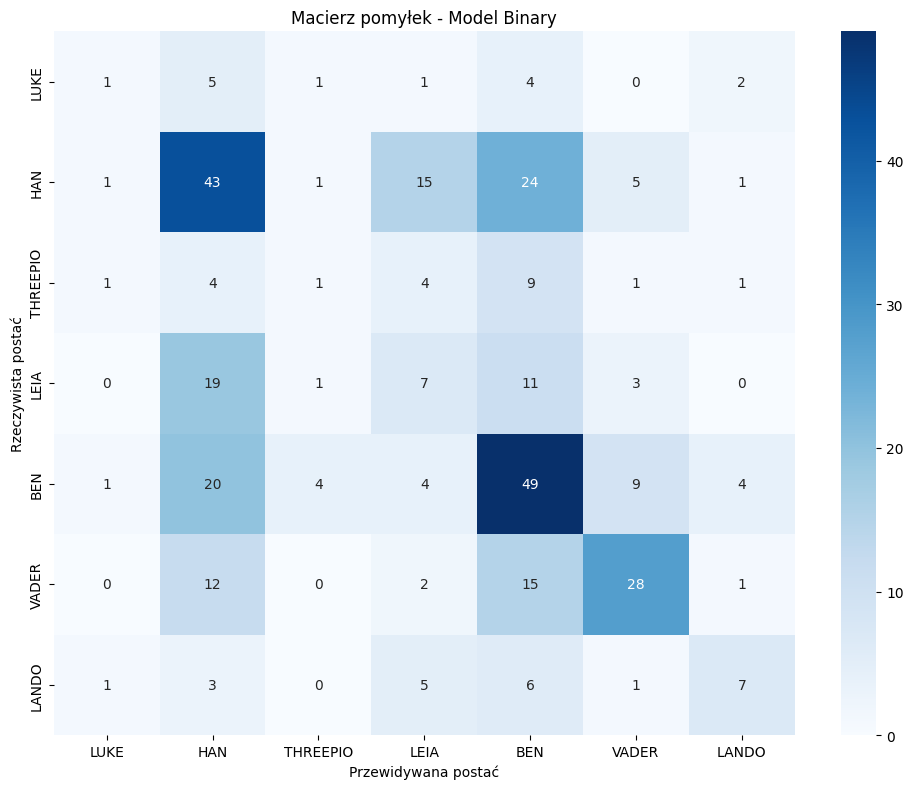

In [38]:
print(classification_report(y_test, y_pred_binary))
plt.figure(figsize=(10, 8))
cm_binary = confusion_matrix(y_test, y_pred_binary)
sns.heatmap(cm_binary, annot=True, fmt='d', cmap='Blues',
            xticklabels=top_7_postaci.keys(),
            yticklabels=top_7_postaci.keys())
plt.title('Macierz pomyłek - Model Binary')
plt.xlabel('Przewidywana postać')
plt.ylabel('Rzeczywista postać')
plt.tight_layout()
plt.savefig('macierz_pomylek_binary.png')
plt.show()

Model SVC z wektoryzacją binarną osiągnął około 40 % dokładności, najlepiej klasyfikuje Threepio (f1 ≈ 0.53) i Luke’a (f1 ≈ 0.47), ale ponad połowę zdań Lei, Lando czy Bena przypisuje błędnie innym postaciom.

##2. Wektoryzacja logarytmiczna

In [39]:
vectorizer_log = CountVectorizer()
X_train_log = vectorizer_log.fit_transform(X_train)
X_test_log = vectorizer_log.transform(X_test)
X_train_log = np.log1p(X_train_log.toarray())
X_test_log = np.log1p(X_test_log.toarray())

classifier_log = SVC(kernel='linear', probability=True)
classifier_log.fit(X_train_log, y_train)
y_pred_log = classifier_log.predict(X_test_log)
wyniki_log = ocen_klasyfikator(y_test, y_pred_log)

              precision    recall  f1-score   support

         BEN       0.33      0.07      0.12        14
         HAN       0.42      0.56      0.48        90
       LANDO       0.25      0.05      0.08        21
        LEIA       0.20      0.07      0.11        41
        LUKE       0.38      0.60      0.47        91
    THREEPIO       0.69      0.50      0.58        58
       VADER       0.50      0.26      0.34        23

    accuracy                           0.43       338
   macro avg       0.40      0.30      0.31       338
weighted avg       0.42      0.43      0.40       338



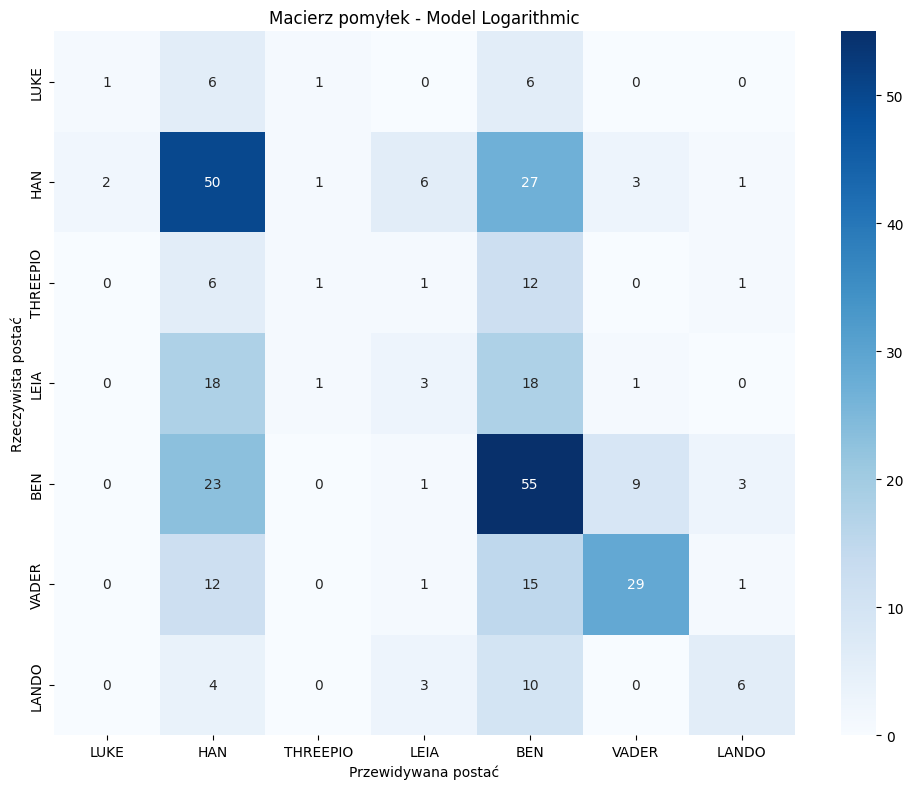

In [40]:
print(classification_report(y_test, y_pred_log))
plt.figure(figsize=(10, 8))
cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues',
            xticklabels=top_7_postaci.keys(),
            yticklabels=top_7_postaci.keys())
plt.title('Macierz pomyłek - Model Logarithmic')
plt.xlabel('Przewidywana postać')
plt.ylabel('Rzeczywista postać')
plt.tight_layout()
plt.savefig('macierz_pomylek_log.png')
plt.show()

Po zastosowaniu log-transformacji termów dokładność wzrosła do 43 %, recall dla Luke’a sięgnął 60 %, a dla Hana 56 %, lecz model nadal myli dialogi Lei i Hana z Benem.

## 3. Wektoryzacja TF-IDF

In [41]:
vectorizer_tfidf = TfidfVectorizer(max_features=1000)
X_train_tfidf = vectorizer_tfidf.fit_transform(X_train)
X_test_tfidf = vectorizer_tfidf.transform(X_test)

classifier_tfidf = SVC(kernel='linear', probability=True)
classifier_tfidf.fit(X_train_tfidf, y_train)
y_pred_tfidf = classifier_tfidf.predict(X_test_tfidf)
wyniki_tfidf = ocen_klasyfikator(y_test, y_pred_tfidf)

              precision    recall  f1-score   support

         BEN       1.00      0.07      0.13        14
         HAN       0.44      0.62      0.51        90
       LANDO       0.00      0.00      0.00        21
        LEIA       0.25      0.07      0.11        41
        LUKE       0.38      0.60      0.47        91
    THREEPIO       0.68      0.52      0.59        58
       VADER       0.44      0.17      0.25        23

    accuracy                           0.44       338
   macro avg       0.46      0.29      0.30       338
weighted avg       0.44      0.44      0.40       338



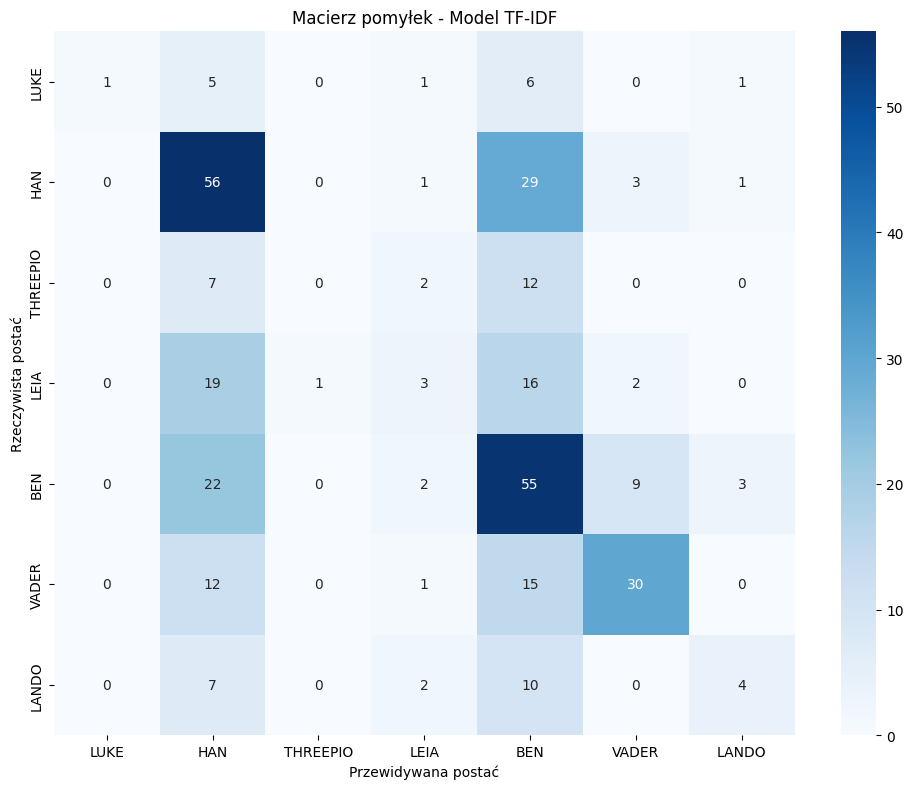

In [42]:
print(classification_report(y_test, y_pred_tfidf))
plt.figure(figsize=(10, 8))
cm_tfidf = confusion_matrix(y_test, y_pred_tfidf)
sns.heatmap(cm_tfidf, annot=True, fmt='d', cmap='Blues',
            xticklabels=top_7_postaci.keys(),
            yticklabels=top_7_postaci.keys())
plt.title('Macierz pomyłek - Model TF-IDF')
plt.xlabel('Przewidywana postać')
plt.ylabel('Rzeczywista postać')
plt.tight_layout()
plt.savefig('macierz_pomylek_tfidf.png')
plt.show()

Wektoryzacja TF-IDF dała najwyższą dokładność 44 % oraz f1 ≈ 0.59 dla Threepio i Luke’a, natomiast Threepio i Lando pozostają niemal nierozpoznani – ich wypowiedzi często trafiają do klas Hana lub Bena.

## 4. Word Embeddings (spaCy)

In [43]:
nlp = spacy.load('en_core_web_sm')

def zdanie_na_wektor(zdanie, nlp):
    doc = nlp(zdanie)
    if len(doc) > 0:
        return doc.vector
    return np.zeros(96)

X_train_w2v = np.array([zdanie_na_wektor(sent, nlp) for sent in X_train])
X_test_w2v = np.array([zdanie_na_wektor(sent, nlp) for sent in X_test])

classifier_w2v = SVC(kernel='linear', probability=True)
classifier_w2v.fit(X_train_w2v, y_train)
y_pred_w2v = classifier_w2v.predict(X_test_w2v)
wyniki_w2v = ocen_klasyfikator(y_test, y_pred_w2v)

              precision    recall  f1-score   support

         BEN       0.10      0.14      0.12        14
         HAN       0.30      0.34      0.32        90
       LANDO       0.00      0.00      0.00        21
        LEIA       0.20      0.10      0.13        41
        LUKE       0.29      0.38      0.33        91
    THREEPIO       0.38      0.34      0.36        58
       VADER       0.18      0.13      0.15        23

    accuracy                           0.28       338
   macro avg       0.21      0.21      0.20       338
weighted avg       0.26      0.28      0.27       338



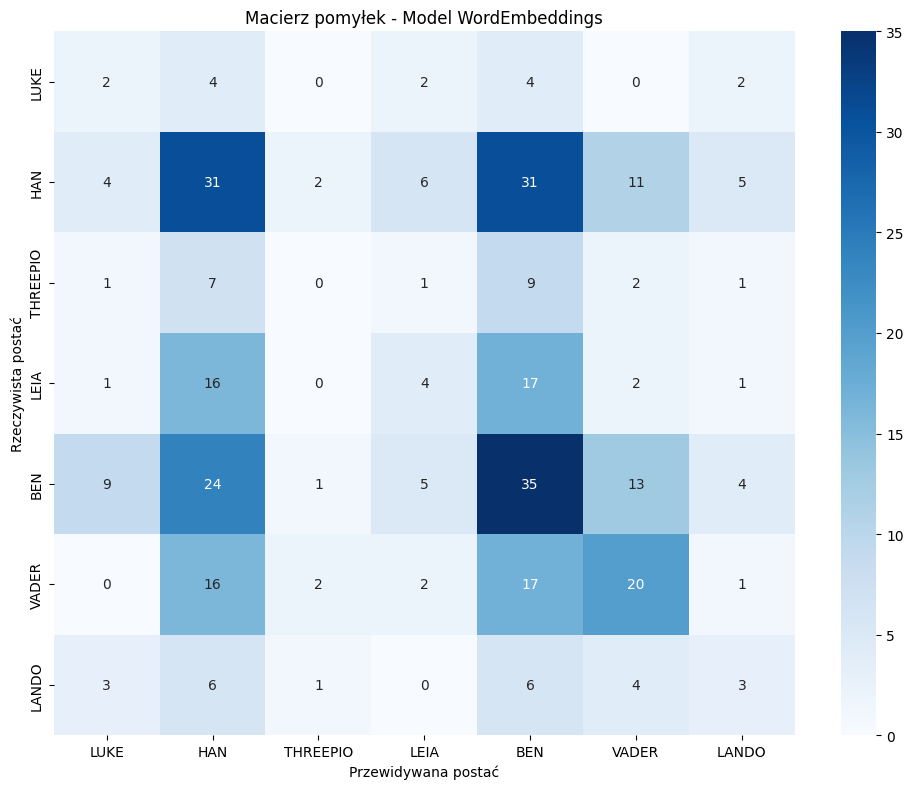

In [44]:
print(classification_report(y_test, y_pred_w2v))
plt.figure(figsize=(10, 8))
cm_w2v = confusion_matrix(y_test, y_pred_w2v)
sns.heatmap(cm_w2v, annot=True, fmt='d', cmap='Blues',
            xticklabels=top_7_postaci.keys(),
            yticklabels=top_7_postaci.keys())
plt.title('Macierz pomyłek - Model WordEmbeddings')
plt.xlabel('Przewidywana postać')
plt.ylabel('Rzeczywista postać')
plt.tight_layout()
plt.savefig('macierz_pomylek_w2v.png')
plt.show()

WordEmbeddings osiągnął najsłabszy wynik 28 % accuracy i f1 < 0.40 dla wszystkich postaci, nie wyodrębniając wyraźnych różnic w słownictwie i silnie myląc głównie Hana, Bena i Vadera.

##Porownanie modeli

In [45]:
wyniki = {
    'Binary': wyniki_binary,
    'Logarithmic': wyniki_log,
    'TF-IDF': wyniki_tfidf,
    'WordEmbeddings': wyniki_w2v
}

df_wyniki = pd.DataFrame(wyniki).T
print("\nPorównanie wyników różnych metod wektoryzacji:")
print(df_wyniki)


Porównanie wyników różnych metod wektoryzacji:
                accuracy  precision    recall        f1
Binary          0.402367   0.390210  0.402367  0.389163
Logarithmic     0.428994   0.421537  0.428994  0.399662
TF-IDF          0.440828   0.439032  0.440828  0.400568
WordEmbeddings  0.281065   0.264965  0.281065  0.268229


Najlepszą skuteczność i zbalansowane metryki (accuracy 44%, precision & recall ≈44%, f1 ≈0.40) uzyskała wektoryzacja TF-IDF, nieco lepsza od logarytmicznej (43% accuracy) i wyraźnie przewyższająca prostą binarną (40% accuracy). Natomiast podejście oparte na word embeddings wypadło najsłabiej (28% accuracy, f1 ≈0.27), co sugeruje, że przy krótkich, zróżnicowanych dialogach prostsze metody count-based lepiej wyłapują typowe cechy słownictwa postaci niż gęste wektory semantyczne.










##wybór najlepszego klasyfikatora do dalszej czesci

In [46]:
najlepsza_metoda = max(wyniki.items(), key=lambda x: x[1]['f1'])[0]
print(f"\nNajlepsza metoda wektoryzacji: {najlepsza_metoda}")

if najlepsza_metoda == 'Binary':
    classifier = classifier_binary
    vectorizer = vectorizer_binary
elif najlepsza_metoda == 'Logarithmic':
    classifier = classifier_log
    vectorizer = vectorizer_log
elif najlepsza_metoda == 'TF-IDF':
    classifier = classifier_tfidf
    vectorizer = vectorizer_tfidf
else:
    classifier = classifier_w2v
    vectorizer = nlp


Najlepsza metoda wektoryzacji: TF-IDF


In [47]:
def przewiduj_postac(tekst):
    przetworzony_tekst = ' '.join(przetworz_tekst_zaawansowanie(tekst))

    if najlepsza_metoda == 'Word2Vec':
        X_new = zdanie_na_wektor(przetworzony_tekst, vectorizer)
        X_new = X_new.reshape(1, -1)
    else:
        X_new = vectorizer.transform([przetworzony_tekst])

    prawdopodobienstwa = classifier.predict_proba(X_new)[0]

    wyniki = dict(zip(classifier.classes_, prawdopodobienstwa))

    wyniki = dict(sorted(wyniki.items(), key=lambda x: x[1], reverse=True))

    return wyniki

## Bonus: rozpoznawanie zdań postaci

In [48]:
while True:
    tekst = input("\nWpisz zdanie do przeanalizowania: ")
    if tekst.lower() == 'koniec':
        break

    wyniki = przewiduj_postac(tekst)

    print("\nPrawdopodobieństwo, że zdanie wypowiedziała dana postać:")
    for postac, prawdopodobienstwo in wyniki.items():
        print(f"{postac}: {prawdopodobienstwo:.2%}")

    najlepsza_postac = max(wyniki.items(), key=lambda x: x[1])
    print(f"\nNajbardziej prawdopodobne, że to {najlepsza_postac[0]} ({najlepsza_postac[1]:.2%})")

KeyboardInterrupt: Interrupted by user

# Analiza sentymentu

##Pomocnicza metoda

In [49]:
def analizuj_sentyment(tekst):
    return TextBlob(tekst).sentiment.polarity

## Analiza sentymentu dla filmów

In [50]:
sentyment_filmy = {}
for film, dialogi in zdania_postaci_filmy.items():
    wszystkie_sentymenty = []
    for dialog in dialogi.values():
        for zdanie in dialog:
            sentyment = analizuj_sentyment(zdanie)
            wszystkie_sentymenty.append(sentyment)
    sentyment_filmy[film] = {
        'sredni': np.mean(wszystkie_sentymenty),
        'mediana': np.median(wszystkie_sentymenty),
        'std': np.std(wszystkie_sentymenty),
        'wszystkie': wszystkie_sentymenty
    }


## Analiza sentymentu dla 7 najczęściej mówiących postaci

In [51]:
top_5_postaci = dict(sorted(laczne_slowa.items(), key=lambda x: x[1], reverse=True)[:7])
sentyment_postaci = {}

for postac in top_5_postaci.keys():
    wszystkie_sentymenty = []
    for dialog in zdania_postaci[postac]:
        sentyment = analizuj_sentyment(dialog)
        wszystkie_sentymenty.append(sentyment)
    sentyment_postaci[postac] = {
        'sredni': np.mean(wszystkie_sentymenty),
        'mediana': np.median(wszystkie_sentymenty),
        'std': np.std(wszystkie_sentymenty),
        'wszystkie': wszystkie_sentymenty
    }

## 1. Wykres pudełkowy sentymentu dla filmów

In [52]:
fig1 = go.Figure()
for film, dane in sentyment_filmy.items():
    fig1.add_trace(go.Box(
        y=dane['wszystkie'],
        name=film,
        boxpoints='outliers',
        jitter=0.3,
        pointpos=-1.8
    ))

fig1.update_layout(
    title='Rozkład sentymentu w dialogach dla każdego filmu',
    yaxis_title='Polaryzacja sentymentu (-1 do 1)',
    showlegend=True,
    height=600
)

fig1.show()
fig1.write_html('sentyment_filmy.html')

W „Nowej nadziei” rozkład sentymentu jest najszerszy – mediana leży blisko zera, ale dialogi zawierają zarówno silnie negatywne, jak i bardzo pozytywne wypowiedzi, co odzwierciedla wprowadzenie wielu dramatycznych i optymistycznych wątków. W „Imperium kontratakuje” sentyment jest niemal w całości skupiony wokół neutralnej wartości, z niespełna obecną szczyptą skrajności, co może być wynikiem bardziej stonowanego, refleksyjnego tonu filmu. „Powrót Jedi” plasuje się pomiędzy obiema poprzednimi – ma umiarkowaną zmienność sentymentu, z lekką przewagą pozytywnych nut przy ostatecznym triumfie bohaterów, ale też kilkoma mocniejszymi negatywnymi akcentami. Ogólnie rzecz biorąc, pierwsza część oferuje największą emocjonalną dynamikę, druga – konsekwentną powściągliwość, a trzecia – zrównoważone połączenie neutralności i nadziei.

## 2. Wykres pudełkowy sentymentu dla postaci

In [53]:
fig2 = go.Figure()
for postac, dane in sentyment_postaci.items():
    fig2.add_trace(go.Box(
        y=dane['wszystkie'],
        name=postac,
        boxpoints='outliers',
        jitter=0.3,
        pointpos=-1.8
    ))

fig2.update_layout(
    title='Rozkład sentymentu w dialogach dla głównych postaci',
    yaxis_title='Polaryzacja sentymentu (-1 do 1)',
    showlegend=True,
    height=600
)
fig2.show()
fig2.write_html('sentyment_postaci.html')

W rozkładzie sentymentu widać, że najbardziej emocjonalnie zróżnicowane są dialogi Luke’a i Hana – ich wypowiedzi rozciągają się od wyraźnie negatywnych po bardzo pozytywne, co dobrze oddaje ich burzliwe losy. C-3PO oraz Leia zachowują niemal całkowitą neutralność (bardzo wąskie pudełka), Lando i Ben plasują się blisko środka skali, z umiarkowanymi wahaniami w obie strony.

## 3. Wykres słupkowy średniego sentymentu

In [54]:
fig3 = make_subplots(rows=1, cols=2, subplot_titles=('Średni sentyment w filmach', 'Średni sentyment postaci'))

fig3.add_trace(
    go.Bar(
        x=list(sentyment_filmy.keys()),
        y=[dane['sredni'] for dane in sentyment_filmy.values()],
        name='Filmy'
    ),
    row=1, col=1
)

fig3.add_trace(
    go.Bar(
        x=list(sentyment_postaci.keys()),
        y=[dane['sredni'] for dane in sentyment_postaci.values()],
        name='Postacie'
    ),
    row=1, col=2
)

fig3.update_layout(
    title_text='Porównanie średniego sentymentu',
    height=600,
    showlegend=False
)
fig3.write_html('sredni_sentyment.html')
fig3.show()

Choć „Powrót Jedi” ma najwyższy średni sentyment (0,048) w porównaniu z „Imperium kontratakuje” (0,036) i „Nową nadzieją” (0,030), wszystkie wartości są jednak bardzo blisko zera, więc praktycznie ton filmów pozostaje neutralny. Podobnie w przypadku postaci – Han ma nieco bardziej pozytywny ślad (0,078), a Threepio niemal zerowy (0,008), ale różnice między bohaterami mieszczą się w kilka setnych punktu. Innymi słowy, mimo że można dostrzec subtelne odchylenia, generalnie dialogi w całej trylogii oscylują wokół neutralnego sentymentu.

## 4. Wykres liniowy ewolucji sentymentu w czasie

In [55]:
fig4 = make_subplots(rows=1, cols=1, subplot_titles=('Ewolucja sentymentu w filmach'))

for film, dane in sentyment_filmy.items():
    ruchoma_srednia = pd.Series(dane['wszystkie']).rolling(window=50).mean()
    fig4.add_trace(
        go.Scatter(
            y=ruchoma_srednia,
            name=film,
            mode='lines'
        ),
        row=1, col=1
    )
fig4.write_html('ewolucja_sentymentu.html')
fig4.show()



Wykres pokazuje, że wszystkie trzy epizody oscylują wokół neutralnej wartości, ale z wyraźnymi momentami wzrostów i spadków odpowiadającymi kluczowym scenom. W „Nowej nadziei” sentyment najpierw delikatnie spada do negatywu (np. podczas ucieczki z Tantive IV), potem rośnie w środkowej części i gwałtownie spada pod koniec, by na finiszu nieco się odbić. „Imperium kontratakuje” ma najbardziej stonowaną trajektorię: wznosi się do szczytu przy treningu u Yody i bitwie na Hoth, potem stopniowo opada w scenie na Bespin, by na koniec znów wrócić w stronę lekkiego optymizmu. „Powrót Jedi” cechuje się krótkim okresem silnie pozytywnego sentymentu, po którym następuje kilkusekundowy spadek emocji i stabilizacja wokół neutralności aż do finału.

##5. Rozkład emocji i heatmap emocji NRC

In [56]:
top_7_postaci = dict(sorted(laczne_slowa.items(), key=lambda x: x[1], reverse=True)[:7])

emocje_postaci = {}
for postac in top_7_postaci.keys():
    wszystkie_emocje = defaultdict(int)
    for zdanie in zdania_postaci[postac]:
        emocje = NRCLex(zdanie)
        for emocja, wartosc in emocje.affect_frequencies.items():
            wszystkie_emocje[emocja] += wartosc

    emocje_postaci[postac] = dict(wszystkie_emocje)

emocje_do_wykresu = []
for postac, emocje in emocje_postaci.items():
    for emocja, wartosc in emocje.items():
        if emocja != 'anticip':
            emocje_do_wykresu.append({
                'Postać': postac,
                'Emocja': emocja,
                'Wartość': wartosc
            })

fig = px.bar(emocje_do_wykresu, x='Postać', y='Wartość', color='Emocja',
             title='Rozkład emocji w dialogach 7 postaci z największą liczbą słów',
             barmode='group')
fig.write_html('emocje_postaci.html')
fig.show()


Wykres pokazuje, że najbardziej „emocjonalnie ekspresyjni” są bohaterowie-weterani: Luke, Han i Threepio – każdy z nich ma wysokie wartości „positive”, „anticipation” i „trust”, co odzwierciedla ich aktywną rolę w akcji i optymistyczny ton wypowiedzi. Luke wyróżnia się najwięcej „fear i „negative”, co może być związane z jego wewnętrznymi rozterkami i niepewnością, podczas gdy Threepio ma najwyższe „positive”  i „trust” oraz bardzo niskie „anger” i „disgust”, podkreślając jego pogodny, służebny charakter. Leia i benowi odpowiadają bardziej stonowane profile — umiarkowane „trust” i „anticipation” przy względnie niskich wartościach ekstremalnych emocji, co wpisuje się w ich rolę dyplomatów i mentorów.

##Mapa cieplna emocji w dialogach postaci

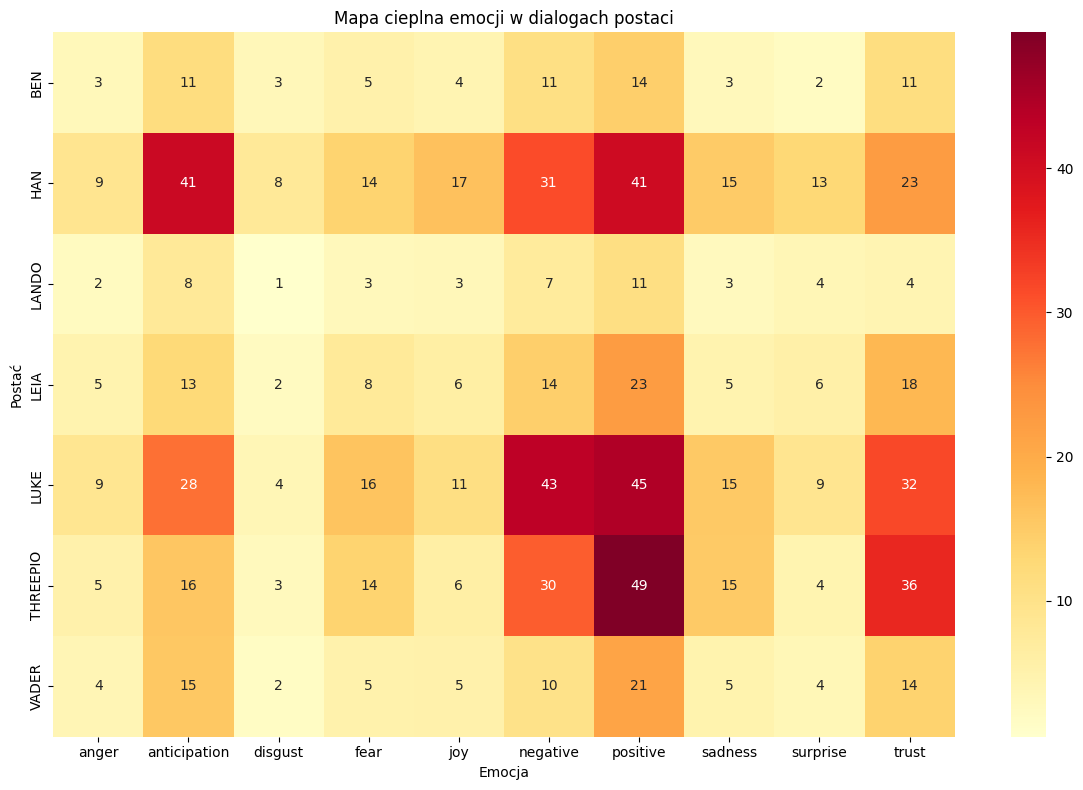

In [57]:
emocje_df = pd.DataFrame(emocje_do_wykresu)
emocje_pivot = emocje_df.pivot(index='Postać', columns='Emocja', values='Wartość')
plt.figure(figsize=(12, 8))
sns.heatmap(emocje_pivot, annot=True, cmap='YlOrRd', fmt='.0f')
plt.title('Mapa cieplna emocji w dialogach postaci')
plt.tight_layout()
plt.savefig('emocje_heatmap.png')
plt.show()

Mapa cieplna wyraźnie pokazuje, że najbardziej „emocjonalnie gęste” są dialogi Luke’a, Hana i Threepio – wszyscy trzej mają wysokie wartości zarówno „positive” (od 41 do 49), jak i „negative” (30–45), co świadczy o ich dużej ekspresji i zmienności nastroju. Threepio jest pod tym względem najbardziej skrajny w pozytywach (49) i zaufaniu (36), a jednocześnie ma sporo „negative” (30), co odzwierciedla jego skłonność do panikowania i szybkich zwrotów emocji. Luke wyróżnia się największą liczbą wyrazów związanych ze smutkiem (15) i negatywem (43), a także zaufaniem (32), co dobrze koresponduje z jego wewnętrzną podróżą i chwilami wątpliwości.